In [1]:

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp


def newton_step(z):
    z = np.asarray(z, dtype=np.complex128)
    numerator = z**3 - 1
    denominator = 3 * z**2
    update = np.zeros_like(z)
    np.divide(numerator, denominator, out=update, where=denominator != 0)
    return z - update


def schroeder_step(z):
    z = np.asarray(z, dtype=np.complex128)
    target = 3 + 1j
    pz = (z**2 - 1) * (z - target)
    dp = 2 * z * (z - target) + (z**2 - 1)
    d2p = 6 * z - 2 * target  # Corregido: p''(z) = 6z - 2(3+i)
    
    lp = np.zeros_like(z)
    denom_lp = dp**2
    np.divide(pz * d2p, denom_lp, out=lp, where=denom_lp != 0)
    
    ratio = np.zeros_like(z)
    np.divide(pz, dp, out=ratio, where=dp != 0)
    
    correction = np.zeros_like(z)
    np.divide(ratio, 1 - lp, out=correction, where=(1 - lp) != 0)
    
    return z - correction

# def schroeder_step(z):
#     z = np.asarray(z, dtype=np.complex128)
#     target = 3 + 1j
#     pz = (z**2 - 1) * (z - target)
#     dp = 2 * z * (z - target) + (z**2 - 1)
#     d2p = 2 * (z - target) + 2 * z
#     ratio = np.zeros_like(z)
#     np.divide(pz, dp, out=ratio, where=dp != 0)
#     lp = np.zeros_like(z)
#     denom_lp = dp**2
#     np.divide(pz * d2p, denom_lp, out=lp, where=denom_lp != 0)
#     correction = np.zeros_like(z)
#     np.divide(ratio, 1 - lp, out=correction, where=(1 - lp) != 0)
#     return z - correction


def root_position(z_values, roots, labels, tol=1e-6):
    z = np.asarray(z_values)
    distances = np.abs(z[..., None] - roots)
    closest = distances.argmin(axis=-1)
    min_dist = distances.min(axis=-1)
    result = np.zeros(z.shape, dtype=int)
    mask = min_dist < tol
    result[mask] = labels[closest[mask]]
    return result


def compute_basins(step_func, roots, labels, x_range, y_range, points, limit, tol=1e-6):
    xs = np.linspace(x_range[0], x_range[1], points)
    ys = np.linspace(y_range[1], y_range[0], points)
    grid = xs[None, :] + 1j * ys[:, None]
    current = grid.copy()
    iter_counts = np.zeros(grid.shape, dtype=int)
    root_ids = np.zeros(grid.shape, dtype=int)

    for _ in range(limit):
        active = root_ids == 0
        if not np.any(active):
            break
        iter_counts[active] += 1
        updated = step_func(current[active])
        current[active] = updated
        new_ids = root_position(updated, roots, labels, tol=tol)
        if np.any(new_ids):
            stored = root_ids[active]
            mask = new_ids > 0
            stored[mask] = new_ids[mask]
            root_ids[active] = stored

    values = root_ids.astype(float) + iter_counts / (limit + 0.001)
    return xs, ys, root_ids, iter_counts, values


def cmyk_to_rgb(c, m, y, k):
    c = np.clip(np.asarray(c, dtype=float), 0.0, 1.0)
    m = np.clip(np.asarray(m, dtype=float), 0.0, 1.0)
    y = np.clip(np.asarray(y, dtype=float), 0.0, 1.0)
    k = np.clip(np.asarray(k, dtype=float), 0.0, 1.0)
    r = 1.0 - np.minimum(1.0, c + k)
    g = 1.0 - np.minimum(1.0, m + k)
    b = 1.0 - np.minimum(1.0, y + k)
    return np.stack([r, g, b], axis=-1)


def colors_case1(values):
    labels = values.astype(int)
    rgb = np.zeros(values.shape + (3,), dtype=float)
    rgb[labels == 3] = (1.0, 0.0, 0.0)
    rgb[labels == 2] = (0.0, 1.0, 0.0)
    rgb[labels == 1] = (0.0, 0.0, 1.0)
    return rgb


def colors_case2(values):
    labels = values.astype(int)
    frac = np.modf(values)[0]
    pp = 0.4 * frac
    rgb = np.zeros(values.shape + (3,), dtype=float)
    mask3 = labels == 3
    mask2 = labels == 2
    mask1 = labels == 1
    if np.any(mask3):
        rgb[mask3] = cmyk_to_rgb(0.6 + pp[mask3], 0.0, 0.0, 2 * pp[mask3])
    if np.any(mask2):
        rgb[mask2] = cmyk_to_rgb(0.0, 0.6 + pp[mask2], 0.0, 2 * pp[mask2])
    if np.any(mask1):
        rgb[mask1] = cmyk_to_rgb(0.0, 0.0, 0.6 + pp[mask1], 2 * pp[mask1])
    return rgb


def show_fractal(xs, ys, colors, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(colors, origin='upper', extent=[xs.min(), xs.max(), ys.min(), ys.max()])
    # ax.set_xlabel('Re(z)')
    # ax.set_ylabel('Im(z)')
    # ax.set_title(title)
    plt.show()


Calculando cuenca para (z-1)^2(z+1)...
Iteraciones máximas: 47

Distribución de convergencia:
  → Raíz z=1:   2871230 puntos ( 68.46%)
  → Raíz z=-1:  1323074 puntos ( 31.54%)
  → No converge:      0 puntos (  0.00%)


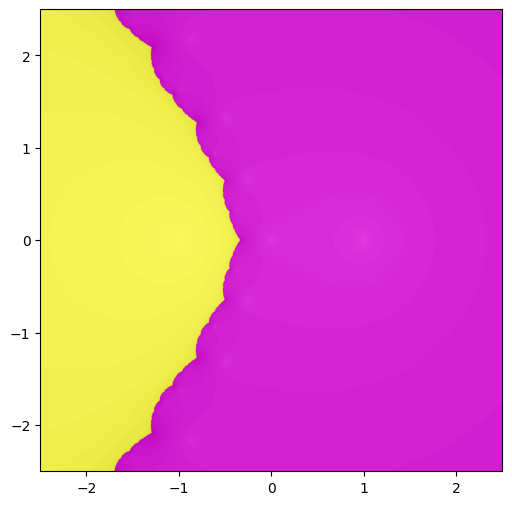

Imagen guardada: img/newton_(z-1)^2(z+1).png


In [4]:
import os

def newton_step_z_minus_1_power_n_z_plus_1(z, n):
    """Método de Newton para p(z) = (z-1)^n(z+1)"""
    z = np.asarray(z, dtype=np.complex128)
    
    # p(z) = (z-1)^n(z+1)
    pz = (z - 1)**n * (z + 1)
    
    # p'(z) = n(z-1)^(n-1)(z+1) + (z-1)^n
    #       = (z-1)^(n-1)[n(z+1) + (z-1)]
    #       = (z-1)^(n-1)[(n+1)z + (n-1)]
    dp = (z - 1)**(n-1) * ((n+1)*z + (n-1))
    
    update = np.zeros_like(z)
    np.divide(pz, dp, out=update, where=dp != 0)
    
    return z - update

# Parámetros comunes
roots_newton = np.array([1 + 0j, -1 + 0j], dtype=np.complex128)
labels_newton = np.array([2, 1])
x_range_newton = (-2.5, 2.5)
y_range_newton = (-2.5, 2.5)
points_newton = 1024*2
lim_newton = 100

# Caso n=2: (z-1)^2(z+1)
print("="*80)
print("Calculando cuenca para (z-1)^2(z+1)...")
xs_n2, ys_n2, root_ids_n2, counts_n2, values_n2 = compute_basins(
    lambda z: newton_step_z_minus_1_power_n_z_plus_1(z, 2),
    roots_newton,
    labels_newton,
    x_range_newton,
    y_range_newton,
    points_newton,
    lim_newton,
)

print(f"Iteraciones máximas: {counts_n2.max()}")

# Calcular porcentajes de convergencia
total_points_n2 = root_ids_n2.size
points_to_root1_n2 = np.sum(root_ids_n2 == 2)  # Label 2 = raíz z=1
points_to_root_minus1_n2 = np.sum(root_ids_n2 == 1)  # Label 1 = raíz z=-1
points_no_converge_n2 = np.sum(root_ids_n2 == 0)

pct_root1_n2 = 100 * points_to_root1_n2 / total_points_n2
pct_root_minus1_n2 = 100 * points_to_root_minus1_n2 / total_points_n2
pct_no_conv_n2 = 100 * points_no_converge_n2 / total_points_n2

print(f"\nDistribución de convergencia:")
print(f"  → Raíz z=1:  {points_to_root1_n2:8d} puntos ({pct_root1_n2:6.2f}%)")
print(f"  → Raíz z=-1: {points_to_root_minus1_n2:8d} puntos ({pct_root_minus1_n2:6.2f}%)")
print(f"  → No converge: {points_no_converge_n2:6d} puntos ({pct_no_conv_n2:6.2f}%)")

# Colores
labels_n2 = values_n2.astype(int)
frac_n2 = np.modf(values_n2)[0]
pp_n2 = 0.4 * frac_n2
colors_n2 = np.zeros(values_n2.shape + (3,), dtype=float)
mask2_n2 = labels_n2 == 2
mask1_n2 = labels_n2 == 1
if np.any(mask2_n2):
    colors_n2[mask2_n2] = cmyk_to_rgb(0.0, 0.6 + pp_n2[mask2_n2], 0.0, 2 * pp_n2[mask2_n2])
if np.any(mask1_n2):
    colors_n2[mask1_n2] = cmyk_to_rgb(0.0, 0.0, 0.6 + pp_n2[mask1_n2], 2 * pp_n2[mask1_n2])

show_fractal(xs_n2, ys_n2, colors_n2, "Newton: $(z-1)^2(z+1)$")

# Guardar
os.makedirs('img', exist_ok=True)
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(colors_n2, origin='upper', extent=[xs_n2.min(), xs_n2.max(), ys_n2.min(), ys_n2.max()])
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both', which='both', length=5, width=1)
plt.savefig('img/newton_(z-1)^2(z+1).png', dpi=300, bbox_inches='tight')
plt.close()
print("Imagen guardada: img/newton_(z-1)^2(z+1).png")


# Traducción de cálculos desde LaParabola.nb

## Función racional y puntos fijos

Basado en el archivo de Mathematica, analizamos la función:
$$f(z) = \frac{1 + z + 2z^2}{1 + 3z}$$

Y buscamos las soluciones de las ecuaciones:
- $f(z) = -1/3$ (puntos fijos de orden 1)
- $f(f(z)) = -1/3$ (puntos fijos de orden 2)
- $f(f(f(z))) = -1/3$ (puntos fijos de orden 3)
- etc.

In [5]:
import numpy as np
import sympy as sp
from sympy import symbols, solve, nsimplify, N

# Definir la variable simbólica
z = symbols('z')

# Definir la función racional f(z) = (1 + z + 2z^2)/(1 + 3z)
def f_symb(z):
    return (1 + z + 2*z**2)/(1 + 3*z)

# 1. Resolver f(z) = -1/3
print("="*80)
print("1. Puntos fijos de orden 1: f(z) = -1/3")
print("="*80)
eq1 = f_symb(z) + sp.Rational(1, 3)
sols1 = solve(eq1, z)
print(f"Soluciones exactas: {sols1}")
print("\nSoluciones numéricas:")
for sol in sols1:
    val_num = complex(N(sol))
    print(f"  z = {val_num.real:.16f} + {val_num.imag:.16f}i")

# 2. Resolver f(f(z)) = -1/3
print("\n" + "="*80)
print("2. Puntos fijos de orden 2: f(f(z)) = -1/3")
print("="*80)
eq2 = f_symb(f_symb(z)) + sp.Rational(1, 3)
sols2 = solve(eq2, z)
print(f"Número de soluciones: {len(sols2)}")
print("\nSoluciones numéricas:")
for i, sol in enumerate(sols2, 1):
    val_num = complex(N(sol))
    print(f"  z{i} = {val_num.real:.16f} + {val_num.imag:.16f}i")

# 3. Resolver f(f(f(z))) = -1/3
print("\n" + "="*80)
print("3. Puntos fijos de orden 3: f(f(f(z))) = -1/3")
print("="*80)
# Advertencia: esto puede ser lento
eq3 = f_symb(f_symb(f_symb(z))) + sp.Rational(1, 3)
sols3 = solve(eq3, z)
print(f"Número de soluciones: {len(sols3)}")
print("\nPrimeras 8 soluciones numéricas:")
for i, sol in enumerate(sols3[:8], 1):
    val_num = complex(N(sol))
    print(f"  z{i} = {val_num.real:.16f} + {val_num.imag:.16f}i")

1. Puntos fijos de orden 1: f(z) = -1/3
Soluciones exactas: [-1/2 - sqrt(15)*I/6, -1/2 + sqrt(15)*I/6]

Soluciones numéricas:
  z = -0.5000000000000000 + -0.6454972243679028i
  z = -0.5000000000000000 + 0.6454972243679028i

2. Puntos fijos de orden 2: f(f(z)) = -1/3
Número de soluciones: 4

Soluciones numéricas:
  z1 = -0.4464798191812115 + 0.3068381774548130i
  z2 = -0.8035201808187884 + 1.2750840140066670i
  z3 = -0.4464798191812115 + -0.3068381774548130i
  z4 = -0.8035201808187884 + -1.2750840140066670i

3. Puntos fijos de orden 3: f(f(f(z))) = -1/3
Número de soluciones: 8

Primeras 8 soluciones numéricas:
  z1 = -1.2912993557438888 + -2.0884443522738771i
  z2 = -1.2912993557438888 + 2.0884443522738771i
  z3 = -0.6719520936156282 + -0.8947511521059914i
  z4 = -0.6719520936156282 + 0.8947511521059914i
  z5 = -0.4139809154842939 + -0.1758183312638764i
  z6 = -0.4139809154842939 + 0.1758183312638764i
  z7 = -0.4977676351561892 + -0.4344938859237721i
  z8 = -0.4977676351561892 + 0.43449

In [6]:
# Extraer puntos para el ajuste lineal
# Basado en los datos del archivo Mathematica
datos = [
    (-1/3, 0),
    (-0.5, 0.6454972243679027),
    (-0.8035201808187874, -1.2750840140066675),
    (-0.8035201808187874, 1.2750840140066675),
    (-1.2912993557438488, 2.0884443522737923),
    (-2.046920333167267, 3.239860238742131)
]

print("="*80)
print("Datos extraídos (parte real, parte imaginaria):")
print("="*80)
for i, (re, im) in enumerate(datos, 1):
    print(f"Punto {i}: ({re:.16f}, {im:.16f})")

# Realizar ajuste lineal usando numpy
x_data = np.array([d[1] for d in datos])  # parte imaginaria
y_data = np.array([d[0] for d in datos])  # parte real

# Ajuste lineal: y = mx + b
coeffs = np.polyfit(x_data, y_data, 1)
m, b = coeffs

print(f"\n" + "="*80)
print(f"Ajuste lineal: y = mx + b")
print(f"="*80)
print(f"Pendiente (m): {m:.16f}")
print(f"Ordenada (b):  {b:.16f}")
print(f"\nEcuación de la recta: y = {m:.6f}x + ({b:.6f})")

# Verificar el ajuste
print(f"\n" + "="*80)
print("Verificación del ajuste:")
print("="*80)
print(f"{'Im(z)':<20} {'Re(z) real':<20} {'Re(z) ajustado':<20} {'Error':<15}")
print("-"*80)
for x, y in zip(x_data, y_data):
    y_pred = m * x + b
    error = abs(y - y_pred)
    print(f"{x:<20.6f} {y:<20.6f} {y_pred:<20.6f} {error:<15.8f}")

Datos extraídos (parte real, parte imaginaria):
Punto 1: (-0.3333333333333333, 0.0000000000000000)
Punto 2: (-0.5000000000000000, 0.6454972243679027)
Punto 3: (-0.8035201808187874, -1.2750840140066675)
Punto 4: (-0.8035201808187874, 1.2750840140066675)
Punto 5: (-1.2912993557438488, 2.0884443522737923)
Punto 6: (-2.0469203331672672, 3.2398602387421311)

Ajuste lineal: y = mx + b
Pendiente (m): -0.3098778679767543
Ordenada (b):  -0.6545740689358699

Ecuación de la recta: y = -0.309878x + (-0.654574)

Verificación del ajuste:
Im(z)                Re(z) real           Re(z) ajustado       Error          
--------------------------------------------------------------------------------
0.000000             -0.333333            -0.654574            0.32124074     
0.645497             -0.500000            -0.854599            0.35459937     
-1.275084            -0.803520            -0.259454            0.54406643     
1.275084             -0.803520            -1.049694            0.24617420

In [26]:
# Interpolación parabólica con todos los puntos fijos
print("\n" + "="*80)
print("INTERPOLACIÓN PARABÓLICA")
print("="*80)

# Recolectar solo el punto -1/3 y los puntos de orden 1
puntos_todos = []

# Punto fijo principal -1/3
puntos_todos.append((-1/3, 0))

# Orden 1
for sol in sols1:
    val = complex(N(sol))
    puntos_todos.append((val.real, val.imag))

print(f"\nTotal de puntos recolectados: {len(puntos_todos)}")
print("  - Punto principal: z = -1/3 + 0i")
print(f"  - Puntos de orden 1: {len(sols1)}")

# Preparar datos para ajuste parabólico: Re(z) = a*Im(z)^2 + b*Im(z) + c
# Con la restricción de que pase por el punto (-1/3, 0)
x_parab = np.array([p[1] for p in puntos_todos])  # Im(z)
y_parab = np.array([p[0] for p in puntos_todos])  # Re(z)

# Forzar que la parábola pase por (-1/3, 0): Re(-1/3) cuando Im=0
# Esto significa que c = -1/3
# Entonces ajustamos: Re(z) = a*Im(z)^2 + b*Im(z) - 1/3
c = -1/3
y_parab_adjusted = y_parab - c  # Re(z) - c = a*Im(z)^2 + b*Im(z)

# Ajuste cuadrático para a y b (sin término independiente)
# Construir matriz de diseño para regresión lineal
X_design = np.column_stack([x_parab**2, x_parab])
coeffs_ab = np.linalg.lstsq(X_design, y_parab_adjusted, rcond=None)[0]
a, b = coeffs_ab

print(f"\nAjuste cuadrático: Re(z) = a·Im(z)² + b·Im(z) + c")
print(f"(con restricción: pasa por el punto z = -1/3 + 0i)")
print(f"="*80)
print(f"Coeficiente a (cuadrático): {a:.10f}")
print(f"Coeficiente b (lineal):     {b:.10f}")
print(f"Coeficiente c (constante):  {c:.10f} (fijado = -1/3)")
print(f"\nEcuación: Re(z) = {a:.6f}·Im(z)² + {b:.6f}·Im(z) + ({c:.6f})")

# Calcular R² para evaluar la calidad del ajuste
y_pred_parab = a * x_parab**2 + b * x_parab + c
ss_res = np.sum((y_parab - y_pred_parab)**2)
ss_tot = np.sum((y_parab - np.mean(y_parab))**2)
r_squared = 1 - (ss_res / ss_tot)

print(f"\nCalidad del ajuste:")
print(f"  R² = {r_squared:.8f}")
print(f"  Error cuadrático medio: {np.sqrt(ss_res/len(y_parab)):.8f}")

# Mostrar algunos ejemplos de ajuste
print(f"\n" + "="*80)
print("Verificación del ajuste (primeros 10 puntos):")
print("="*80)
print(f"{'Im(z)':<20} {'Re(z) real':<20} {'Re(z) ajustado':<20} {'Error':<15}")
print("-"*80)
for i in range(min(10, len(x_parab))):
    y_pred = a * x_parab[i]**2 + b * x_parab[i] + c
    error = abs(y_parab[i] - y_pred)
    print(f"{x_parab[i]:<20.6f} {y_parab[i]:<20.6f} {y_pred:<20.6f} {error:<15.8f}")

# ============================================================================
# SEGUNDA PARÁBOLA: -1/3 y los 2 puntos de orden 3 con mayor |Im(z)|
# ============================================================================
print("\n" + "="*80)
print("SEGUNDA INTERPOLACIÓN PARABÓLICA (Orden 3)")
print("="*80)

# Recolectar puntos de orden 3
puntos_orden3 = []
for sol in sols3:
    val = complex(N(sol))
    puntos_orden3.append((val.real, val.imag))

# Ordenar por valor absoluto de la parte imaginaria (descendente)
puntos_orden3_sorted = sorted(puntos_orden3, key=lambda p: abs(p[1]), reverse=True)

# Tomar los 2 con mayor |Im(z)|
puntos_parab2 = [(-1/3, 0)]  # Punto fijo principal
puntos_parab2.extend(puntos_orden3_sorted[:2])

print(f"\nPuntos seleccionados para la segunda parábola:")
for i, (re, im) in enumerate(puntos_parab2):
    print(f"  Punto {i+1}: z = {re:.6f} + {im:.6f}i  (|Im| = {abs(im):.6f})")

# Ajuste de la segunda parábola
x_parab2 = np.array([p[1] for p in puntos_parab2])  # Im(z)
y_parab2 = np.array([p[0] for p in puntos_parab2])  # Re(z)

c2 = -1/3
y_parab2_adjusted = y_parab2 - c2

X_design2 = np.column_stack([x_parab2**2, x_parab2])
coeffs_ab2 = np.linalg.lstsq(X_design2, y_parab2_adjusted, rcond=None)[0]
a2, b2 = coeffs_ab2

print(f"\nAjuste cuadrático (Parábola 2): Re(z) = a₂·Im(z)² + b₂·Im(z) + c₂")
print(f"(con restricción: pasa por el punto z = -1/3 + 0i)")
print(f"="*80)
print(f"Coeficiente a₂ (cuadrático): {a2:.10f}")
print(f"Coeficiente b₂ (lineal):     {b2:.10f}")
print(f"Coeficiente c₂ (constante):  {c2:.10f} (fijado = -1/3)")
print(f"\nEcuación: Re(z) = {a2:.6f}·Im(z)² + {b2:.6f}·Im(z) + ({c2:.6f})")

# ============================================================================
# POLINOMIO DE GRADO 6: -1/3, orden 1, orden 2 (2 mayores |Im|), orden 3 (2 mayores |Im|)
# ============================================================================
print("\n" + "="*80)
print("INTERPOLACIÓN POLINÓMICA DE GRADO 6")
print("="*80)

# Recolectar puntos de orden 2
puntos_orden2 = []
for sol in sols2:
    val = complex(N(sol))
    puntos_orden2.append((val.real, val.imag))

# Ordenar por valor absoluto de la parte imaginaria (descendente)
puntos_orden2_sorted = sorted(puntos_orden2, key=lambda p: abs(p[1]), reverse=True)

# Construir lista de puntos para el polinomio
puntos_poly = []
puntos_poly.append((-1/3, 0))  # Punto fijo principal

# Orden 1: todos
for sol in sols1:
    val = complex(N(sol))
    puntos_poly.append((val.real, val.imag))

# Orden 2: los 2 con mayor |Im(z)|
puntos_poly.extend(puntos_orden2_sorted[:2])

# Orden 3: los 2 con mayor |Im(z)| (ya calculados antes)
puntos_poly.extend(puntos_orden3_sorted[:2])

print(f"\nTotal de puntos para interpolación: {len(puntos_poly)}")
print(f"\nPuntos seleccionados:")
for i, (re, im) in enumerate(puntos_poly):
    if i == 0:
        print(f"  {i+1}. Punto principal: z = {re:.6f} + {im:.6f}i")
    elif i <= 2:
        print(f"  {i+1}. Orden 1: z = {re:.6f} + {im:.6f}i  (|Im| = {abs(im):.6f})")
    elif i <= 4:
        print(f"  {i+1}. Orden 2: z = {re:.6f} + {im:.6f}i  (|Im| = {abs(im):.6f})")
    else:
        print(f"  {i+1}. Orden 3: z = {re:.6f} + {im:.6f}i  (|Im| = {abs(im):.6f})")

# Ajuste polinómico: Re(z) = sum(p_i * Im(z)^i) para i=0 a 6
x_poly = np.array([p[1] for p in puntos_poly])  # Im(z)
y_poly = np.array([p[0] for p in puntos_poly])  # Re(z)

# Usar polyfit con grado 6 (7 puntos determinan un polinomio de grado 6)
grado_poly = len(puntos_poly) - 1
coeffs_poly = np.polyfit(x_poly, y_poly, grado_poly)

print(f"\nAjuste polinómico de grado {grado_poly}:")
print(f"Re(z) = p₀·Im(z)⁶ + p₁·Im(z)⁵ + p₂·Im(z)⁴ + p₃·Im(z)³ + p₄·Im(z)² + p₅·Im(z) + p₆")
print(f"="*80)
for i, coef in enumerate(coeffs_poly):
    potencia = grado_poly - i
    print(f"  p_{i} (coef. grado {potencia}): {coef:.10f}")

# Verificar el ajuste
y_pred_poly = np.polyval(coeffs_poly, x_poly)
error_max_poly = np.max(np.abs(y_poly - y_pred_poly))
print(f"\nError máximo del ajuste polinómico: {error_max_poly:.2e}")
print(f"(debería ser prácticamente cero para interpolación exacta)")

# Mostrar verificación
print(f"\n" + "="*80)
print("Verificación del ajuste polinómico:")
print("="*80)
print(f"{'Im(z)':<20} {'Re(z) real':<20} {'Re(z) ajustado':<20} {'Error':<15}")
print("-"*80)
for i in range(len(x_poly)):
    y_pred = np.polyval(coeffs_poly, x_poly[i])
    error = abs(y_poly[i] - y_pred)
    print(f"{x_poly[i]:<20.6f} {y_poly[i]:<20.6f} {y_pred:<20.6f} {error:<15.10f}")


INTERPOLACIÓN PARABÓLICA

Total de puntos recolectados: 3
  - Punto principal: z = -1/3 + 0i
  - Puntos de orden 1: 2

Ajuste cuadrático: Re(z) = a·Im(z)² + b·Im(z) + c
(con restricción: pasa por el punto z = -1/3 + 0i)
Coeficiente a (cuadrático): -0.4000000000
Coeficiente b (lineal):     0.0000000000
Coeficiente c (constante):  -0.3333333333 (fijado = -1/3)

Ecuación: Re(z) = -0.400000·Im(z)² + 0.000000·Im(z) + (-0.333333)

Calidad del ajuste:
  R² = 1.00000000
  Error cuadrático medio: 0.00000000

Verificación del ajuste (primeros 10 puntos):
Im(z)                Re(z) real           Re(z) ajustado       Error          
--------------------------------------------------------------------------------
0.000000             -0.333333            -0.333333            0.00000000     
-0.645497            -0.500000            -0.500000            0.00000000     
0.645497             -0.500000            -0.500000            0.00000000     

SEGUNDA INTERPOLACIÓN PARABÓLICA (Orden 3)

Puntos

## Dibujo del fractal con la recta superpuesta

Ahora dibujamos la cuenca de atracción para $m=2$ con la recta ajustada superpuesta, replicando el gráfico del archivo de Mathematica.


Marcando puntos fijos en el gráfico:
  Punto fijo principal: z = -1/3 + 0i
  Orden 1, punto 1: z = -0.500000 + -0.645497i
  Orden 1, punto 2: z = -0.500000 + 0.645497i
  Orden 2, punto 1: z = -0.446480 + 0.306838i
  Orden 2, punto 2: z = -0.803520 + 1.275084i
  Orden 2, punto 3: z = -0.446480 + -0.306838i
  Orden 2, punto 4: z = -0.803520 + -1.275084i
  Orden 3, punto 1: z = -1.291299 + -2.088444i
  Orden 3, punto 2: z = -1.291299 + 2.088444i
  Orden 3, punto 3: z = -0.671952 + -0.894751i
  Orden 3, punto 4: z = -0.671952 + 0.894751i
  Orden 3, punto 5: z = -0.413981 + -0.175818i
  Orden 3, punto 6: z = -0.413981 + 0.175818i
  Orden 3, punto 7: z = -0.497768 + -0.434494i
  Orden 3, punto 8: z = -0.497768 + 0.434494i


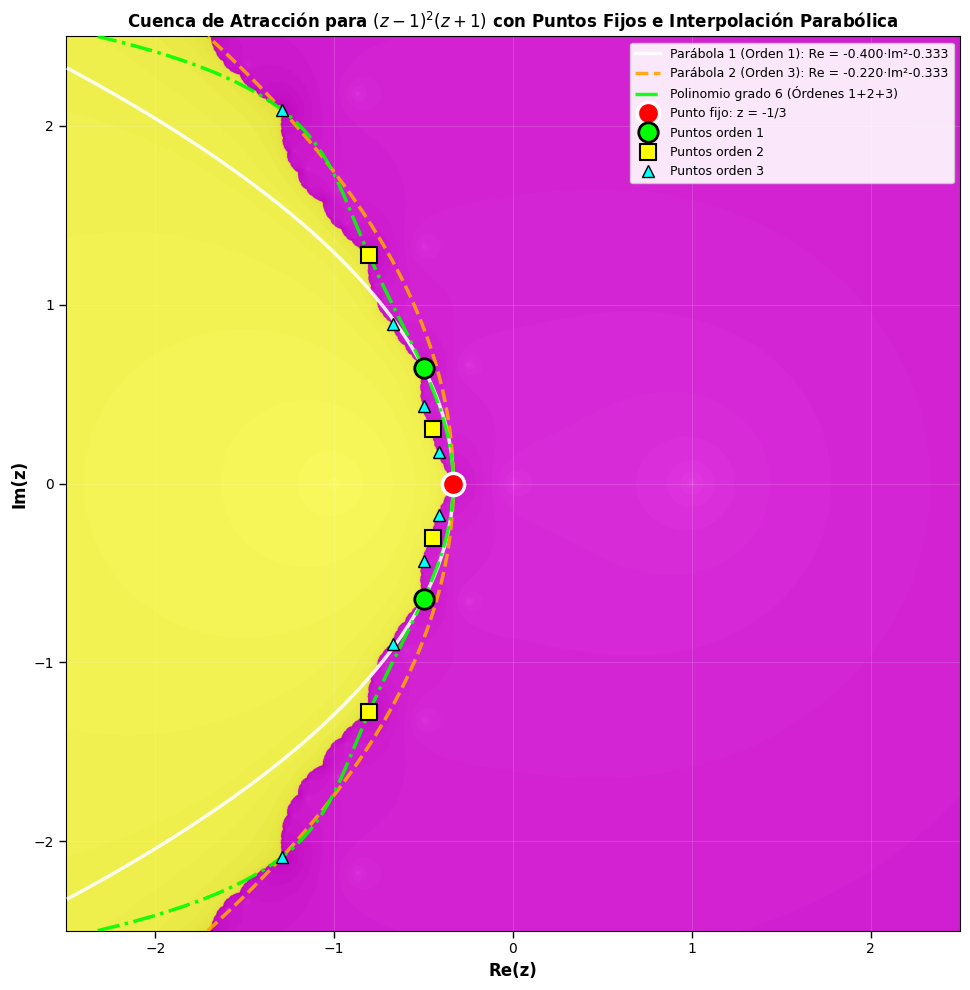


Imagen guardada: img/newton_(z-1)^2(z+1)_con_parabola.png
Parábola interpolada: Re(z) = -0.400000·Im(z)² + 0.000000·Im(z) + -0.333333


In [27]:
# Dibujar el fractal con todos los puntos fijos superpuestos y la parábola interpolada
fig, ax = plt.subplots(figsize=(10, 10))

# Mostrar la cuenca de atracción
# extent = [x_min, x_max, y_min, y_max] donde x=Re(z), y=Im(z)
extent = [xs_n2.min(), xs_n2.max(), ys_n2.min(), ys_n2.max()]
ax.imshow(colors_n2, origin='upper', extent=extent)

# Dibujar la primera parábola (orden 1)
im_vals_parab = np.linspace(ys_n2.min(), ys_n2.max(), 500)
re_vals_parab = a * im_vals_parab**2 + b * im_vals_parab + c
# Filtrar puntos que estén dentro del rango del gráfico
mask_parab = (re_vals_parab >= xs_n2.min()) & (re_vals_parab <= xs_n2.max())
ax.plot(re_vals_parab[mask_parab], im_vals_parab[mask_parab], 
        '-', color='white', linewidth=2.5, alpha=0.9,
        label=f'Parábola 1 (Orden 1): Re = {a:.3f}·Im²{c:.3f}', zorder=7)

# Dibujar la segunda parábola (orden 3)
re_vals_parab2 = a2 * im_vals_parab**2 + b2 * im_vals_parab + c2
mask_parab2 = (re_vals_parab2 >= xs_n2.min()) & (re_vals_parab2 <= xs_n2.max())
ax.plot(re_vals_parab2[mask_parab2], im_vals_parab[mask_parab2], 
        '--', color='orange', linewidth=2.5, alpha=0.9,
        label=f'Parábola 2 (Orden 3): Re = {a2:.3f}·Im²{c2:.3f}', zorder=7)

# Dibujar el polinomio de grado 6
re_vals_poly = np.polyval(coeffs_poly, im_vals_parab)
mask_poly = (re_vals_poly >= xs_n2.min()) & (re_vals_poly <= xs_n2.max())
ax.plot(re_vals_poly[mask_poly], im_vals_parab[mask_poly], 
        '-.', color='lime', linewidth=2.5, alpha=0.9,
        label=f'Polinomio grado 6 (Órdenes 1+2+3)', zorder=7)

# Marcar todos los puntos fijos calculados
# IMPORTANTE: el fractal usa Re(z) en eje X e Im(z) en eje Y
print("\nMarcando puntos fijos en el gráfico:")

# Marcar el punto -1/3 (punto fijo principal)
ax.plot(-1/3, 0, 'o', color='red', markersize=16, 
        markeredgecolor='white', markeredgewidth=2.5,
        label='Punto fijo: z = -1/3', zorder=11)
print(f"  Punto fijo principal: z = -1/3 + 0i")

# Puntos de orden 1: f(z) = -1/3
for i, sol in enumerate(sols1, 1):
    val = complex(N(sol))
    re_val, im_val = val.real, val.imag
    if xs_n2.min() <= re_val <= xs_n2.max() and ys_n2.min() <= im_val <= ys_n2.max():
        # ax.plot(x, y) donde x=Re(z), y=Im(z)
        ax.plot(re_val, im_val, 'o', color='lime', markersize=14, 
                markeredgecolor='black', markeredgewidth=2,
                label='Puntos orden 1' if i == 1 else '', zorder=10)
        print(f"  Orden 1, punto {i}: z = {re_val:.6f} + {im_val:.6f}i")

# Puntos de orden 2: f(f(z)) = -1/3
for i, sol in enumerate(sols2, 1):
    val = complex(N(sol))
    re_val, im_val = val.real, val.imag
    if xs_n2.min() <= re_val <= xs_n2.max() and ys_n2.min() <= im_val <= ys_n2.max():
        ax.plot(re_val, im_val, 's', color='yellow', markersize=11, 
                markeredgecolor='black', markeredgewidth=1.5,
                label='Puntos orden 2' if i == 1 else '', zorder=9)
        print(f"  Orden 2, punto {i}: z = {re_val:.6f} + {im_val:.6f}i")

# Puntos de orden 3: f(f(f(z))) = -1/3
for i, sol in enumerate(sols3, 1):
    val = complex(N(sol))
    re_val, im_val = val.real, val.imag
    if xs_n2.min() <= re_val <= xs_n2.max() and ys_n2.min() <= im_val <= ys_n2.max():
        ax.plot(re_val, im_val, '^', color='cyan', markersize=9, 
                markeredgecolor='black', markeredgewidth=1,
                label='Puntos orden 3' if i == 1 else '', zorder=8)
        print(f"  Orden 3, punto {i}: z = {re_val:.6f} + {im_val:.6f}i")

ax.set_xlim(xs_n2.min(), xs_n2.max())
ax.set_ylim(ys_n2.min(), ys_n2.max())
ax.set_xlabel('Re(z)', fontsize=12, fontweight='bold')
ax.set_ylabel('Im(z)', fontsize=12, fontweight='bold')
ax.set_title('Cuenca de Atracción para $(z-1)^2(z+1)$ con Puntos Fijos e Interpolación Parabólica', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.tick_params(axis='both', which='both', length=5, width=1)
ax.grid(True, alpha=0.2, color='white', linewidth=0.5)

plt.tight_layout()
plt.savefig('img/newton_(z-1)^2(z+1)_con_parabola.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nImagen guardada: img/newton_(z-1)^2(z+1)_con_parabola.png")
print(f"Parábola interpolada: Re(z) = {a:.6f}·Im(z)² + {b:.6f}·Im(z) + {c:.6f}")

## Resumen de los cálculos traducidos

Los cálculos principales del archivo de Mathematica `LaParabola.nb` incluyen:

1. **Definición de la función racional**: $f(z) = \frac{1 + z + 2z^2}{1 + 3z}$

2. **Búsqueda de puntos fijos de diferentes órdenes**:
   - Orden 1: Soluciones de $f(z) = -1/3$ (2 soluciones)
   - Orden 2: Soluciones de $f(f(z)) = -1/3$ (4 soluciones)
   - Orden 3: Soluciones de $f(f(f(z))) = -1/3$ (8 soluciones)
   - Orden 4: Soluciones de $f^4(z) = -1/3$ (16 soluciones)

3. **Ajuste lineal**: Se extraen algunos puntos representativos de las soluciones y se ajusta una recta que describe el comportamiento asintótico de estos puntos fijos en el plano complejo.

4. **Visualización**: Se grafica la cuenca de atracción del método de Newton aplicado al polinomio $(z-1)^2(z+1)$ junto con la recta ajustada, mostrando la relación entre los puntos fijos y la geometría de las cuencas.

Este análisis permite entender cómo los puntos fijos de diferentes órdenes se distribuyen en el plano complejo y cómo se relacionan con las fronteras de las cuencas de atracción.